In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
base_path = r"C:\Users\FATIMA\OneDrive\Documents\plant_disease_project\dataset"

train_dir = os.path.join(base_path, "train")
val_dir   = os.path.join(base_path, "val")

In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [5]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transforms)

num_classes = len(train_dataset.classes)
print("Classes:", num_classes)

Classes: 15


In [6]:
class_counts = Counter([label for _, label in train_dataset.samples])

total_samples = len(train_dataset)

class_weights = torch.tensor([
    total_samples / (num_classes * class_counts[i])
    for i in range(num_classes)
], dtype=torch.float)

sample_weights = [class_weights[label] for _, label in train_dataset.samples]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,   # ✔ handles imbalance
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [8]:
class MLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(224*224*3, 512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [9]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [10]:
def train_model(model, train_loader, val_loader, epochs=5):

    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):

        # 🔹 TRAIN
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = 100 * correct / total
        train_acc_list.append(train_acc)

        # 🔹 VALIDATION
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        val_acc_list.append(val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%")

    return train_acc_list, val_acc_list

In [11]:
mlp_model = MLP(num_classes)
mlp_train_acc, mlp_val_acc = train_model(mlp_model, train_loader, val_loader)

c:\Users\FATIMA\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/5] | Train: 18.17% | Val: 33.18%
Epoch [2/5] | Train: 29.47% | Val: 36.13%
Epoch [3/5] | Train: 34.77% | Val: 42.41%
Epoch [4/5] | Train: 37.55% | Val: 42.51%
Epoch [5/5] | Train: 40.42% | Val: 43.90%


In [12]:
cnn_model = CNN(num_classes)
cnn_train_acc, cnn_val_acc = train_model(cnn_model, train_loader, val_loader)

Epoch [1/5] | Train: 64.06% | Val: 79.05%
Epoch [2/5] | Train: 81.48% | Val: 87.60%
Epoch [3/5] | Train: 85.30% | Val: 88.70%
Epoch [4/5] | Train: 87.15% | Val: 87.67%
Epoch [5/5] | Train: 89.09% | Val: 89.67%


In [13]:
torch.save({
    "model_state_dict": cnn_model.state_dict(),
    "num_classes": num_classes,
    "class_names": train_dataset.classes
}, "best_model_full.pth")

print("✅ Best CNN model saved")

✅ Best CNN model saved


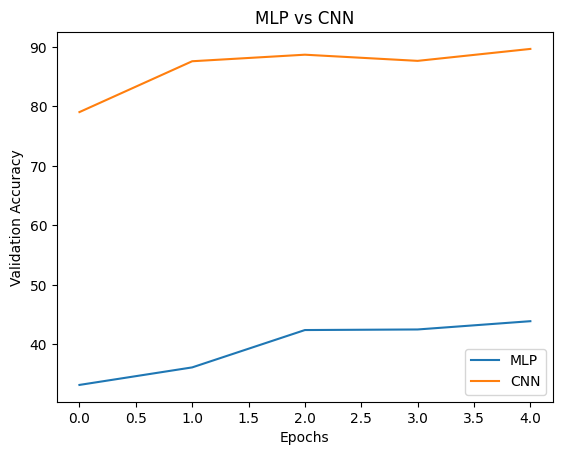

In [14]:
plt.plot(mlp_val_acc, label="MLP")
plt.plot(cnn_val_acc, label="CNN")

plt.title("MLP vs CNN")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()